# Uncertainty Explainer — Demo Workflow

1. **Data**: synthetic regression with feature names (DataFrame)
2. **Conformal prediction**: `CrepesConformalPredictor` (default) and `CQRConformalPredictor` (alternative)
3. **Explainability**: SHAP, PDP, and LIME (local and global)
4. **Pipeline**: `UncertaintyExplanationPipeline` integrates conformal + XAI

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split

from uncertainty_explainer import (
    CQRConformalPredictor,
    UncertaintyExplanationPipeline,
)

## 1. Data

We generate a synthetic dataset and wrap it in a `DataFrame` so that feature names propagate automatically to the explanations.

In [ ]:
X, y = make_regression(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    noise=25.0,
    random_state=42,
)

feature_names = [f"feat_{i}" for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_calib, X_test, y_calib, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape[0]}, Calibration: {X_calib.shape[0]}, Test: {X_test.shape[0]}")
X_train.head()

## 2. Quickstart (3 lines): most basic case for a user

The minimal API only requires a model. `conformal_method`, `confidence`, `xai_method`, and the calibration split all use sensible defaults. The `ExplanationResult` already carries the intervals (`lower`, `upper`, `interval_width`) — there is no need to call `predict()` separately.

In [ ]:
quick = UncertaintyExplanationPipeline(model=RandomForestRegressor(random_state=42))
quick.fit(X_train, y_train)
result = quick.explain(X_test, show_plots=False)

print(f"Coverage: {np.mean((y_test >= result.lower) & (y_test <= result.upper)):.3f}")
print(f"Mean interval width: {result.interval_width.mean():.2f}")

> **Note — `predict()` vs `explain()`**: `explain()` already calls the conformal predictor internally, so the returned `ExplanationResult` contains `lower`, `upper`, and `interval_width` along with the XAI values. If you are going to explain anyway, the intervals come for free — there is no need to call `predict()` separately. Use `predict()` only when you want intervals without the cost of SHAP/LIME/PDP (e.g., production inference).

## 3. Standard flow — Crepes + SHAP

The default pipeline uses `CrepesConformalPredictor` (method `normalized`) and `ShapUncertaintyExplainer`.

**Supported conformal methods** (`conformal_method`):
- `"standard"` — fixed width for all instances
- `"normalized"` — adaptive width via `DifficultyEstimator` (default)
- `"mondrian"` — group-conditional coverage via `MondrianCategorizer`
- `"normalized_mondrian"` — combines both

In [22]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

pipeline_shap = UncertaintyExplanationPipeline(
    model=model,
    confidence=0.9,
    conformal_method="normalized",
    xai_method="shap",
)

pipeline_shap.fit(X_train, y_train, X_calib, y_calib)

In [ ]:
lower, upper = pipeline_shap.predict(X_test)
coverage = np.mean((y_test >= lower) & (y_test <= upper))

print(f"Empirical coverage (nominal=0.9): {coverage:.3f}")
print(f"Mean interval width:              {(upper - lower).mean():.2f}")

ExactExplainer explainer: 201it [01:07,  2.22it/s]                         


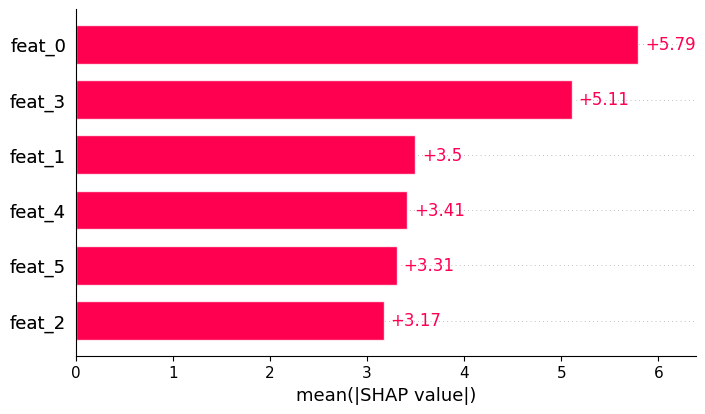

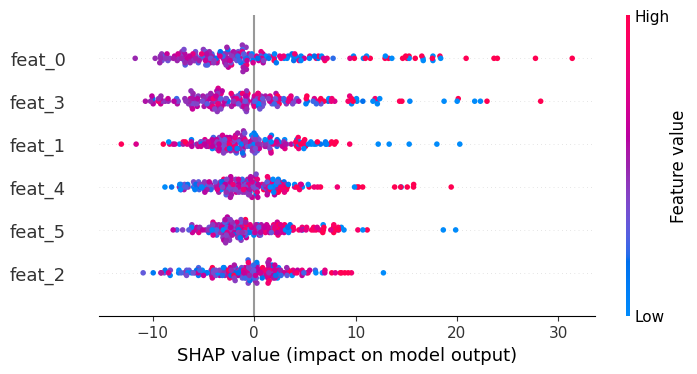

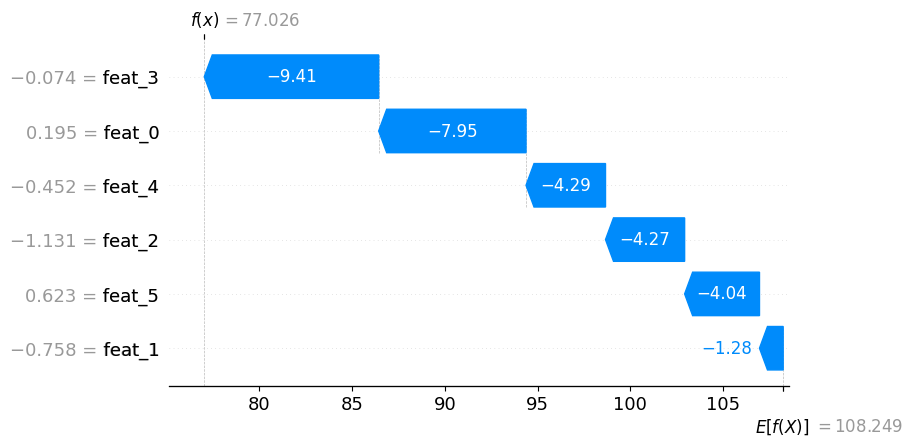

In [24]:
result_shap = pipeline_shap.explain(X_test)

In [ ]:
print("ExplanationResult fields:", list(vars(result_shap).keys()))
print(f"SHAP values shape: {result_shap.explanation_values.values.shape}")
print(f"\nMean interval width: {result_shap.interval_width.mean():.2f}")
print(f"Min interval width:  {result_shap.interval_width.min():.2f}")
print(f"Max interval width:  {result_shap.interval_width.max():.2f}")

## 4. Alternative explainer — PDP

`PDPUncertaintyExplainer` builds Partial Dependence Plots over the interval-width function.

**Supported kinds**: `"pdp"`, `"ice"`, `"pdp_ice"`, `"importance"` (Greenwell et al.-style importance — standard deviation of the PDP curve).

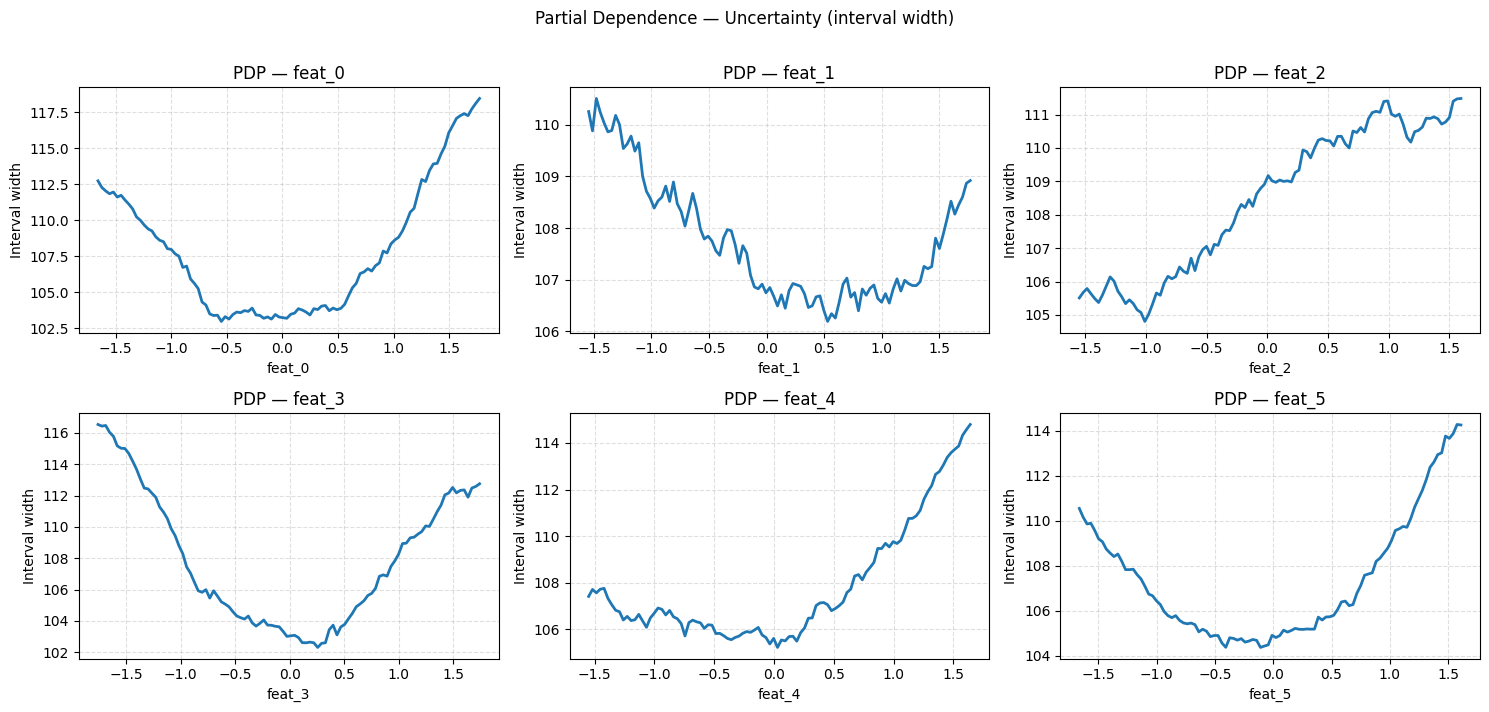

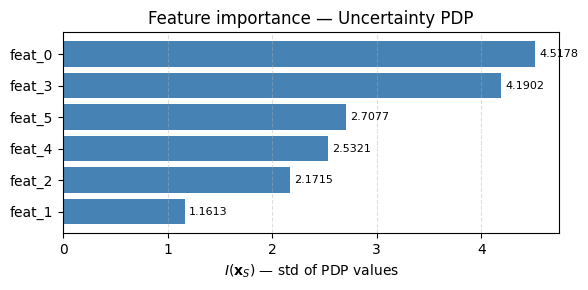

In [26]:
pipeline_pdp = UncertaintyExplanationPipeline(
    model=RandomForestRegressor(n_estimators=100, random_state=42),
    confidence=0.9,
    conformal_method="normalized",
    xai_method="pdp",
)

pipeline_pdp.fit(X_train, y_train, X_calib, y_calib)
result_pdp = pipeline_pdp.explain(
    X_test,
    plot_kind=["pdp", "importance"],
    kind="average",
)

In [27]:
pdp_exp = result_pdp.explanation_values
print(f"PDP values shape:  {pdp_exp.values.shape}  (n_features, grid_resolution)")
print(f"Feature names:     {pdp_exp.feature_names}")
print(f"Grid[0] range:     [{pdp_exp.grid_values[0].min():.2f}, {pdp_exp.grid_values[0].max():.2f}]")

PDP values shape:  (6, 100)  (n_features, grid_resolution)
Feature names:     ['feat_0', 'feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5']
Grid[0] range:     [-1.66, 1.77]


## 5. Alternative explainer — LIME local

`LimeUncertaintyExplainer(scope="local")` produces one linear explanation per sample. The `waterfall_index` parameter (reused as `sample_index`) selects which sample is plotted.

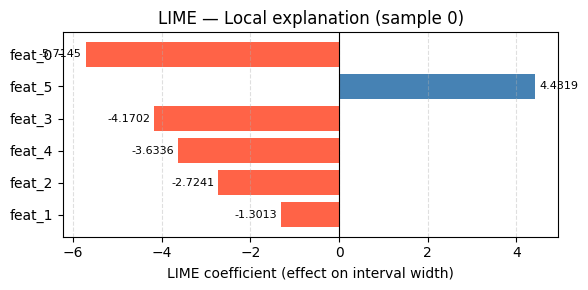

In [28]:
pipeline_lime_local = UncertaintyExplanationPipeline(
    model=RandomForestRegressor(n_estimators=100, random_state=42),
    confidence=0.9,
    xai_method="lime",
    lime_scope="local",
    n_lime_samples=1000,
)

pipeline_lime_local.fit(X_train, y_train, X_calib, y_calib)

# LIME is computationally expensive, so we explain only a few test instances
X_small = X_test.iloc[:5]
result_lime_local = pipeline_lime_local.explain(
    X_small,
    waterfall_index=0,
)

In [ ]:
lime_exp = result_lime_local.explanation_values
print(f"Scope:                   {lime_exp.scope}")
print(f"Local coeffs shape:      {lime_exp.local_coefficients.shape}  (n_samples, n_features)")
print(f"Global importance shape: {lime_exp.global_importance.shape}")

print("\nLIME coefficients for sample 0:")
for name, coef in zip(lime_exp.feature_names, lime_exp.local_coefficients[0]):
    print(f"  {name}: {coef:+.4f}")

## 6. Alternative explainer — LIME global

`LimeUncertaintyExplainer(scope="global")` aggregates the local coefficients by averaging their absolute values — a dataset-level feature importance measure derived from local explanations.

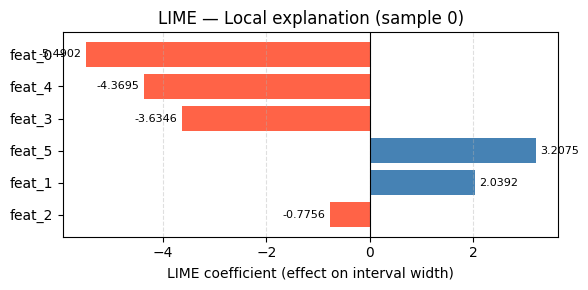

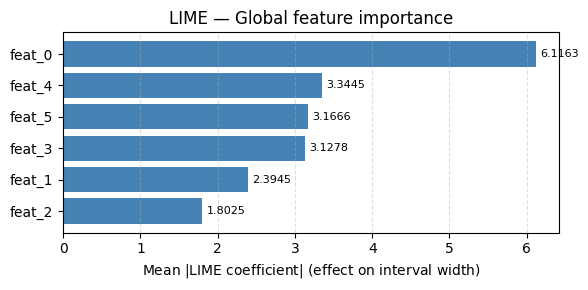

In [30]:
pipeline_lime_global = UncertaintyExplanationPipeline(
    model=RandomForestRegressor(n_estimators=100, random_state=42),
    confidence=0.9,
    xai_method="lime",
    lime_scope="global",
    n_lime_samples=1000,
)

pipeline_lime_global.fit(X_train, y_train, X_calib, y_calib)
result_lime_global = pipeline_lime_global.explain(X_test.iloc[:20])

In [ ]:
g_exp = result_lime_global.explanation_values
print(f"Scope: {g_exp.scope}")
print("\nGlobal importance (mean |LIME coef|):")
order = np.argsort(g_exp.global_importance)[::-1]
for idx in order:
    print(f"  {g_exp.feature_names[idx]}: {g_exp.global_importance[idx]:.4f}")

## 7. Alternative conformal predictor — CQR

`CQRConformalPredictor` implements Conformalized Quantile Regression (Romano et al., 2019). Instead of a single model plus a difficulty estimator, it trains **two quantile models** (one for the lower bound, one for the upper) and calibrates them with nonconformity scores.

We pass it to the pipeline via `conformal_predictor=` and reuse SHAP to explain.

In [ ]:
# Two quantile models: alpha=0.05 (lower) and alpha=0.95 (upper) → 90% intervals
lower_model = GradientBoostingRegressor(loss="quantile", alpha=0.05, n_estimators=100, random_state=42)
upper_model = GradientBoostingRegressor(loss="quantile", alpha=0.95, n_estimators=100, random_state=42)

cqr = CQRConformalPredictor(lower_model, upper_model)

pipeline_cqr = UncertaintyExplanationPipeline(
    conformal_predictor=cqr,
    confidence=0.9,
    xai_method="shap",
)

pipeline_cqr.fit(X_train, y_train, X_calib, y_calib)

In [ ]:
lower_cqr, upper_cqr = pipeline_cqr.predict(X_test)
coverage_cqr = np.mean((y_test >= lower_cqr) & (y_test <= upper_cqr))

print(f"[CQR] Empirical coverage: {coverage_cqr:.3f}")
print(f"[CQR] Mean width:         {(upper_cqr - lower_cqr).mean():.2f}")

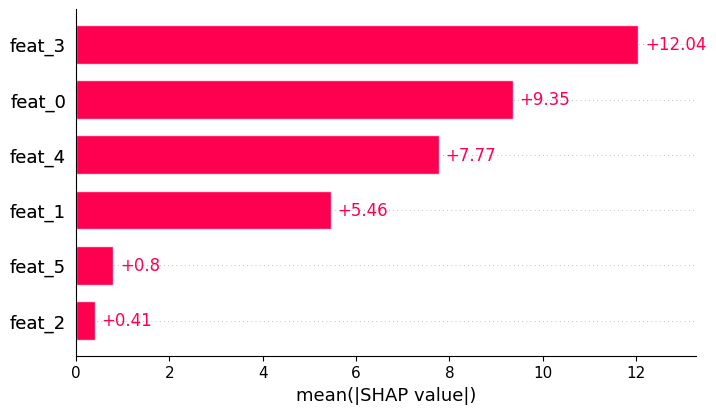

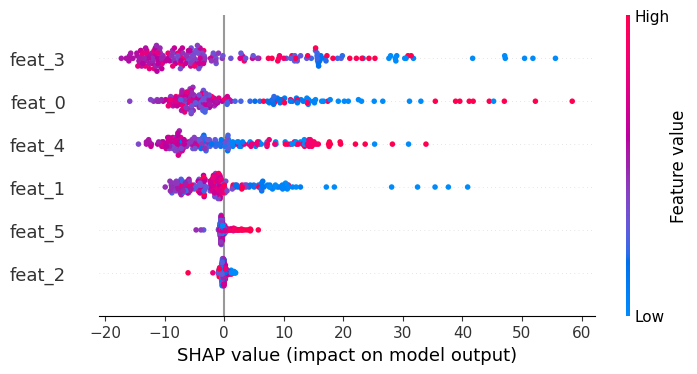

In [34]:
result_cqr = pipeline_cqr.explain(
    X_test,
    plot_kind=["bar", "beeswarm"],
)

## 8. Final comparison

Coverage and mean width per conformal method. Coverage should be close to the nominal value (0.9); a smaller width indicates tighter intervals when coverage is maintained.

In [ ]:
def _summary(lower, upper, y_true, label):
    cov = np.mean((y_true >= lower) & (y_true <= upper))
    width = (upper - lower).mean()
    return {"method": label, "coverage": round(cov, 3), "mean_width": round(width, 2)}

rows = [
    _summary(*pipeline_shap.predict(X_test), y_test, "Crepes (normalized)"),
    _summary(*pipeline_cqr.predict(X_test), y_test, "CQR"),
]

pd.DataFrame(rows)